# 0. Setting Up The Data

In [90]:
pip install ucimlrepo


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [91]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
student_performance_on_an_entrance_examination = fetch_ucirepo(id=582) 
  
# data (as pandas dataframes) 
x = student_performance_on_an_entrance_examination.data.features 
y = student_performance_on_an_entrance_examination.data.targets 
  
# metadata 
print(student_performance_on_an_entrance_examination.metadata) 
  
# variable information 
print(student_performance_on_an_entrance_examination.variables) 


{'uci_id': 582, 'name': 'Student Performance on an Entrance Examination', 'repository_url': 'https://archive.ics.uci.edu/dataset/582/student+performance+on+an+entrance+examination', 'data_url': 'https://archive.ics.uci.edu/static/public/582/data.csv', 'abstract': 'This dataset contains data of the candidates who qualified the medical entrance examination for admission to medical colleges of Assam of a particular year and collected by Prof. Jiten Hazarika.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 666, 'num_features': 11, 'feature_types': [], 'demographics': ['Gender', 'Education Level', 'Occupation'], 'target_col': ['Performance'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Tue Apr 16 2024', 'dataset_doi': '10.24432/C58D0H', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': 'Performance, Gender, Caste, coaching, C

# 1. Business Understanding

The constructed classifier seeks to evaluate and analyse the importance each factor played in students' success in the examination and in turn examine the performance results in the light of these findings.  
The classifier will be built utilising random forest approach.  


# 2. Data Understanding

The dataset provides records of students who passed the medical entrance examination in Assam during a particular year, including their educational background, social category, and parental occupations.

In [92]:
import pandas as pd
from IPython.display import display
pd.set_option('display.max_columns', None) # Show all columns in the output
pd.set_option('display.max_colwidth', None) # Prevent truncation of column content
pd.set_option('display.max_seq_items', None) # Show all items in sequences like arrays/lists

# Inspect first few rows of the data
print("First few rows of x:")
display(x.head())
print("First few rows of y:")
display(y.head())

First few rows of x:


,Gender,Caste,coaching,Class_ten_education,twelve_education,medium,Class_X_Percentage,Class_XII_Percentage,Father_occupation,Mother_occupation,time
0,male,General,NO,SEBA,AHSEC,ENGLISH,Excellent,Excellent,DOCTOR,OTHERS,ONE
1,male,OBC,WA,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,HOUSE_WIFE,TWO
2,male,OBC,OA,OTHERS,CBSE,ENGLISH,Excellent,Excellent,BUSINESS,HOUSE_WIFE,TWO
3,male,General,WA,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,SCHOOL_TEACHER,ONE
4,male,General,OA,SEBA,CBSE,ENGLISH,Excellent,Excellent,COLLEGE_TEACHER,HOUSE_WIFE,TWO


First few rows of y:


,Performance
0,Excellent
1,Excellent
2,Excellent
3,Excellent
4,Excellent


In [93]:
# Check the shape of the data
print("Shape of x:", x.shape)
print("Shape of y:", y.shape)

Shape of x: (666, 11)
Shape of y: (666, 1)


In [94]:
# Check for missing values
print("Information about x:")
x.info()
print("\nInformation about y:")
y.info()

Information about x:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Gender                666 non-null    object
 1   Caste                 666 non-null    object
 2   coaching              666 non-null    object
 3   Class_ten_education   666 non-null    object
 4   twelve_education      666 non-null    object
 5   medium                666 non-null    object
 6   Class_X_Percentage    666 non-null    object
 7   Class_XII_Percentage  666 non-null    object
 8   Father_occupation     666 non-null    object
 9   Mother_occupation     666 non-null    object
 10  time                  666 non-null    object
dtypes: object(11)
memory usage: 57.4+ KB

Information about y:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype 
---  ------    

In [95]:
x.apply(lambda col: pd.Series({
    'Values': col.unique(),
    'Count': col.nunique()
}))

,Gender,Caste,coaching,Class_ten_education,twelve_education,medium,Class_X_Percentage,Class_XII_Percentage,Father_occupation,Mother_occupation,time
Values,"[male, female]","[General, OBC, SC, ST]","[NO, WA, OA]","[SEBA, OTHERS, CBSE]","[AHSEC, CBSE, OTHERS]","[ENGLISH, OTHERS, ASSAMESE]","[Excellent, Vg, Good, Average]","[Excellent, Vg, Good, Average]","[DOCTOR, SCHOOL_TEACHER, BUSINESS, COLLEGE_TEACHER, OTHERS, BANK_OFFICIAL, ENGINEER, CULTIVATOR]","[OTHERS, HOUSE_WIFE, SCHOOL_TEACHER, DOCTOR, COLLEGE_TEACHER, BANK_OFFICIAL, BUSINESS, CULTIVATOR, ENGINEER]","[ONE, TWO, THREE, FOUR, FIVE, SEVEN]"
Count,2,4,3,3,3,3,4,4,8,9,6


In [96]:
y.apply(lambda col: pd.Series({
    'Values': col.unique(),
    'Count': col.nunique()
}))

,Performance
Values,"[Excellent, Vg, Good, Average]"
Count,4


### Dataset
The dataset contains **666** observations and is clean, with no missing values. All variables are stored as string data types. The features and target variable are clearly separated, and no additional attributes such as identifier (**ID**) columns are present. However, the feature **time** lacks documentation describing the meaning of its categorical values, and its interpretation remains unspecified.

### Features
The dataset contains 11 categorical features representing different aspects of a student’s background. These include educational history (such as education boards and medium of instruction), categorized academic performance in Class X and Class XII, social category, participation in coaching programs, and the occupations of both parents. Together, these variables provide insight into both the educational and socioeconomic context of the students.

| Feature              | Type     | Description                        | Values                                                                                                     | Transformation/Encoding                        | Remarks                                                                                                     |
|----------------------|----------|------------------------------------|------------------------------------------------------------------------------------------------------------|------------------------------------------------|-------------------------------------------------------------------------------------------------------------|
| Gender               | Category | Gender of student                  | male/female                                                                                                | Binary (male=0, female=1)                      |                                                                                                             |
| Caste                | Category | Indian caste system                | General, OBC, SC, ST                                                                                       | One-hot encode                                 | General = No reserved category, OBC = Other Backwards Classes, SC = Scheduled Castes, ST = Scheduled Tribes |
| coaching             | Category | Coaching attended                  | NO, WA, OA                                                                                                 | Ordinal (NO=0, WA=1, OA=2)                                | NO = No coaching, WA = Within Assam, OA = Outside Assam                                                     |
| Class_ten_education  | Category | Board for Class X education        | SEBA, OTHERS, CBSE                                                                                         | One-hot encode                                 | SEBA, CBSE = Abbreviations of educational boards                                |
| twelve_education     | Category | Board for Class XII education      | AHSEC, CBSE, OTHERS                                                                                        | One-hot encode                                 | AHSEC, CBSE = Abbreviations of educational boards                              |
| medium               | Category | Medium of instruction at Class XII | ENGLISH, OTHERS, ASSAMESE                                                                                  | One-hot encode                                 |                                                                                                             |
| Class_X_Percentage   | Category | Percentage score in Class X        | Excellent, Vg, Good, Average                                                                               | Ordinal (Excellent=4, Vg=3, Good=2, Average=1) |                                                                                                             |
| Class_XII_Percentage | Category | Percentage score in Class XII      | Excellent, Vg, Good, Average                                                                               | Ordinal (Excellent=4, Vg=3, Good=2, Average=1) |                                                                                                             |
| Father_occupation    | Category | Father's occupation                | DOCTOR, SCHOOL_TEACHER, BUSINESS, COLLEGE_TEACHER, OTHERS, BANK_OFFICIAL, ENGINEER, CULTIVATOR             | One-hot encode                                 |                                                                                                             |
| Mother_occupation    | Category | Mother's occupation                | OTHERS, HOUSE_WIFE, SCHOOL_TEACHER, DOCTOR, COLLEGE_TEACHER, BANK_OFFICIAL, BUSINESS, CULTIVATOR, ENGINEER | One-hot encode                                 |                                                                                                             |
| time                 | Category | Not specified                      | ONE, TWO, THREE, FOUR, FIVE, SEVEN                                                                         | One-hot encoode                                                | Meaning unclear, metadata missing. Using One-hot encoding to not make assumptions in meaning                                                                            |

### Target
The target variable **Performance** describes the student’s outcome in the entrance examination.

| Target      | Type     | Description                          | Values                       | Transformation/Encoding                                 | Remarks         |
|-------------|----------|--------------------------------------|------------------------------|---------------------------------------------------------|-----------------|
| Performance | Category | Student performance in entrance exam | Excellent, Vg, Good, Average | Ordinal (Excellent=4, Vg=3, Good=2, Average=1) | Target variable |

# 3. Data Preparation

The categorical features are transformed into numerical form to prepare the data for modeling. Binary encoding is applied to the **Gender** variable, ordinal encoding is applied to **coaching**, **Class_X_Percentage**, and **Class_XII_Percentage**, and to the target variable **Performance**. Features with more than two categories, including **Caste**, **education boards**, **medium of instruction**, **parental occupations**, and **time**, are converted using one-hot encoding. All resulting boolean columns are converted to integers, producing a fully numeric dataset.

In [97]:
# Copy features and target
x = x.copy()
y = y.copy()
y = y['Performance']

print("Shape of x:", x.shape)
print("Shape of y:", y.shape)

# Binary encoding for Gender
x['Gender'] = x['Gender'].map({'male': 0, 'female': 1})

# Ordinal encoding for coaching
x['coaching'] = x['coaching'].map({'NO': 0, 'WA': 1, 'OA': 2})

# Ordinal encoding for Class_X_Percentage and Class_XII_Percentage
grade_mapping = {'Excellent': 4, 'Vg': 3, 'Good': 2, 'Average': 1}
x['Class_X_Percentage'] = x['Class_X_Percentage'].map(grade_mapping)
x['Class_XII_Percentage'] = x['Class_XII_Percentage'].map(grade_mapping)

# One-hot encoding for categorical features with more than 2 categories
categorical_columns = [
    'Caste', 
    'Class_ten_education', 
    'twelve_education', 
    'medium', 
    'Father_occupation', 
    'Mother_occupation',
    'time',
]
x = pd.get_dummies(x, columns=categorical_columns, drop_first=True)

# Ordinal encoding for the target variable
y = y.map({'Excellent': 4, 'Vg': 3, 'Good': 2, 'Average': 1})

# Convert all boolean columns to integers
x = x.astype({col: int for col in x.select_dtypes('bool').columns})

# Check the first few rows of the transformed data
print("First few rows of transformed x:")
display(x.head())
print("First few rows of transformed y:")
display(y.head().to_frame(name='Performance'))

Shape of x: (666, 11)
Shape of y: (666,)
First few rows of transformed x:


,Gender,coaching,Class_X_Percentage,Class_XII_Percentage,Caste_OBC,Caste_SC,Caste_ST,Class_ten_education_OTHERS,Class_ten_education_SEBA,twelve_education_CBSE,twelve_education_OTHERS,medium_ENGLISH,medium_OTHERS,Father_occupation_BUSINESS,Father_occupation_COLLEGE_TEACHER,Father_occupation_CULTIVATOR,Father_occupation_DOCTOR,Father_occupation_ENGINEER,Father_occupation_OTHERS,Father_occupation_SCHOOL_TEACHER,Mother_occupation_BUSINESS,Mother_occupation_COLLEGE_TEACHER,Mother_occupation_CULTIVATOR,Mother_occupation_DOCTOR,Mother_occupation_ENGINEER,Mother_occupation_HOUSE_WIFE,Mother_occupation_OTHERS,Mother_occupation_SCHOOL_TEACHER,time_FOUR,time_ONE,time_SEVEN,time_THREE,time_TWO
0,0,0,4,4,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
1,0,1,4,4,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1
2,0,2,4,4,1,0,0,1,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
3,0,1,4,4,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0
4,0,2,4,4,0,0,0,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1


First few rows of transformed y:


,Performance
0,4
1,4
2,4
3,4
4,4


After these transformations, the dataset is fully numeric, all features are properly encoded, and everything is ready for modeling. All checks on the transformed data indicate that it is consistent and correctly processed.

# 4. Modeling

### Data Splitting
The data is split into two sets. One for training and one for testing.
* **Training**: 80%
* **Testing**: 20%

In [48]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV Macro F1:", grid.best_score_)

C:\Users\Valvoja\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'class_weight': 'balanced', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Macro F1: 0.4797019232743974


In [52]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test macro F1:", f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test, y_pred))

Best model: RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=10, random_state=42)
Test accuracy: 0.5597014925373134
Test macro F1: 0.5640390569183139
              precision    recall  f1-score   support

           1       0.82      0.84      0.83        32
           2       0.43      0.55      0.48        42
           3       0.54      0.38      0.44        40
           4       0.50      0.50      0.50        20

    accuracy                           0.56       134
   macro avg       0.57      0.57      0.56       134
weighted avg       0.57      0.56      0.56       134



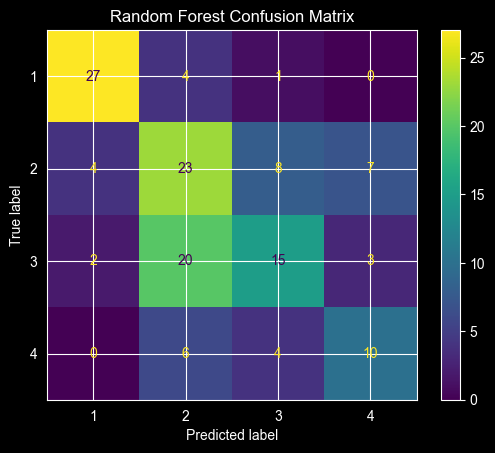


Top 10 important features:
Caste_ST                        0.268979
Class_XII_Percentage            0.066626
Caste_SC                        0.058720
coaching                        0.058174
Caste_OBC                       0.042772
Class_X_Percentage              0.040023
Gender                          0.036640
Mother_occupation_HOUSE_WIFE    0.029036
medium_OTHERS                   0.026601
time_TWO                        0.026022
dtype: float64


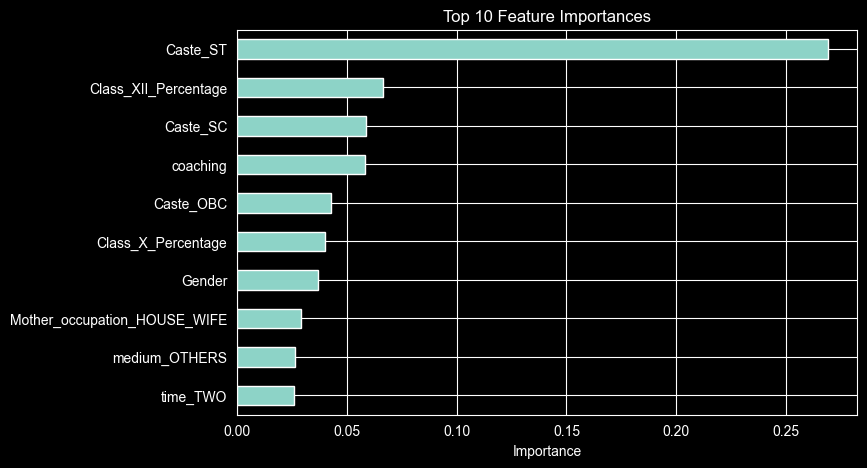

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print("\nTop 10 important features:")
print(importances.head(10))

plt.figure(figsize=(8, 5))
importances.head(10).sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

# 5. Evaluation

# 6. Deployment